In [18]:
# install the input image
!gdown '1FfSpH46ozPWTe1AdTS2NXA_Un8KyZp2z'

Downloading...
From: https://drive.google.com/uc?id=1FfSpH46ozPWTe1AdTS2NXA_Un8KyZp2z
To: /content/cat.jpg
100% 54.3k/54.3k [00:00<00:00, 3.75MB/s]


# Section 1
Read and show the image

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

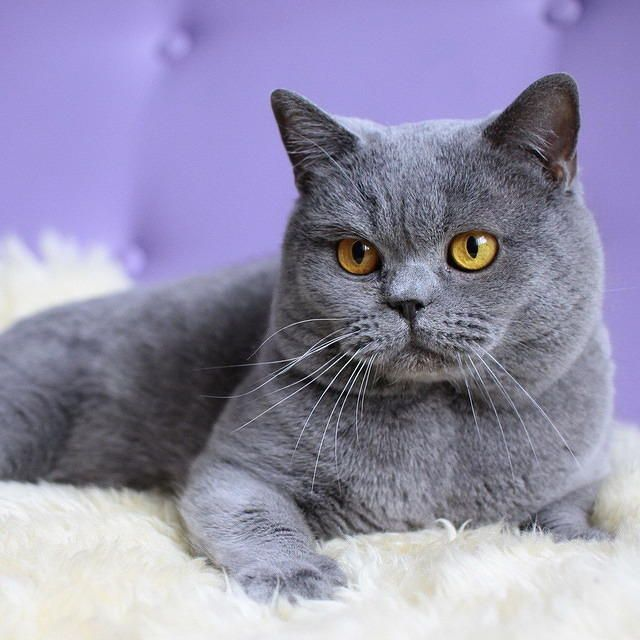

In [20]:
# Answer your code here
cat = cv.imread('/content/cat.jpg', cv.IMREAD_COLOR)
cv2_imshow(cat)

# Section 2
Apply a 3x3 average filter to an input image whose convolution kernel is:

$$
K = \frac{1}{9}
\begin{bmatrix}
1 & 1 & 1  \\
1 & 1 & 1 \\
1 & 1 & 1  \\
\end{bmatrix}
$$

Filter the input image using the function cv.filter2D() and display the results.

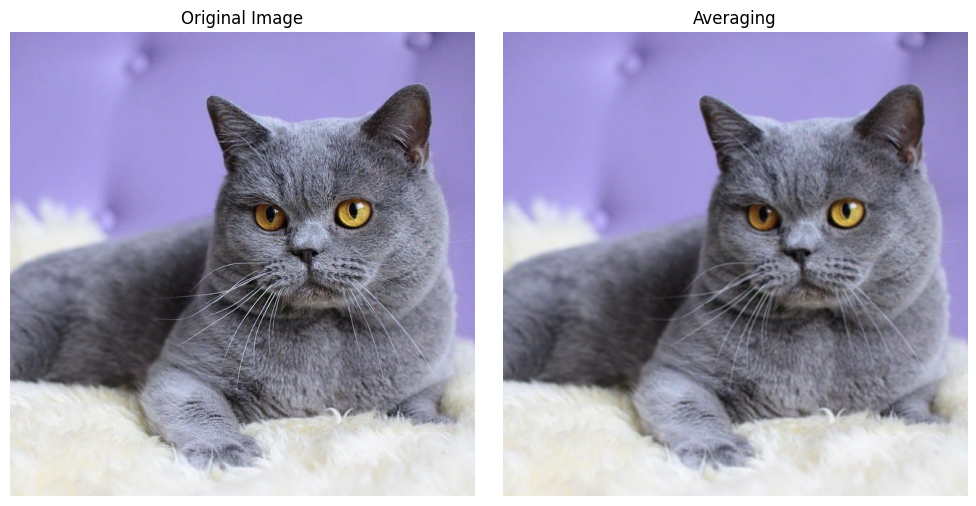

In [21]:
# Answer your code here
kernel = np.ones((3, 3), np.float32) / 9
# ใช้ตัวกรองคอนโวลูชัน (Convolution)
dst_Conv = cv.filter2D(cat, -1, kernel)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(cat, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(dst_Conv, cv.COLOR_BGR2RGB))
plt.title('Averaging')
plt.axis('off')

plt.tight_layout()
plt.show()

# Section 3
- Add Gaussian noise to an image using the provided function add_gaussian_noise().

- Use cv.GaussianBlur() to denoise and adjust the size of the blur kernel (e.g. : (3, 3), (11, 11) etc.) and sigma (e.g., 1, 2, 5 etc). Then observe and explain its influence on the denoising effect.

- Display and compare the following three images (two pairs):

  1. Original image

  2. Image after adding Gaussian noise

  3. Image after applying Gaussian blur

  



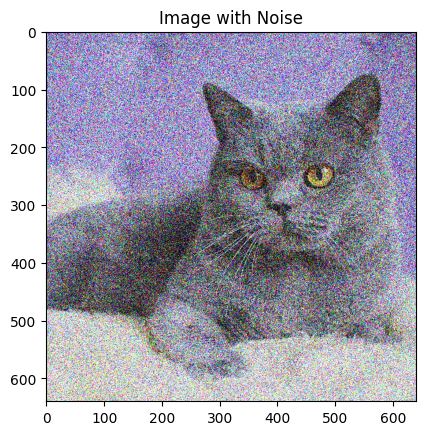

In [22]:
# Adding gaussian noise
def add_gaussian_noise(image, mean=0, sigma=100):
    noise = np.random.normal(mean, sigma, image.shape) # generate noise
    noisy_image = image + noise #  add noise to the image
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

noisy_img = add_gaussian_noise(cat)

plt.imshow(cv.cvtColor(noisy_img, cv.COLOR_BGR2RGB))
plt.title("Image with Noise")
plt.show()

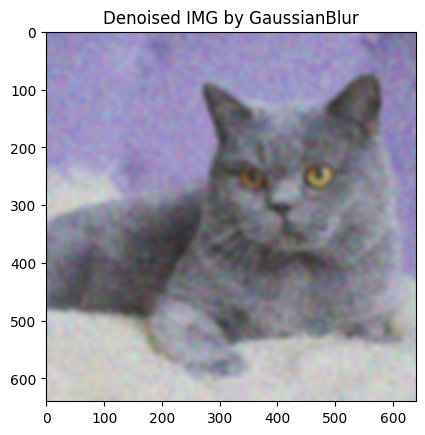

In [23]:
# Answer your code here
# ใช้ Gaussian Blur เพื่อทำให้ภาพเรียบ
Gblur = cv.GaussianBlur(noisy_img,(15,15),5) # sigma is set to 0, so calculates the standard deviation automatically based on kernel size
plt.imshow(cv.cvtColor(Gblur, cv.COLOR_BGR2RGB))
plt.title("Denoised IMG by GaussianBlur")
plt.show()

## **Explain its influence on the denoise**

The Larger Kernel (15x15) & Larger Sigma (5)
Most of the noise will be removed, but significant detail loss occurs, making the image appear overly smooth.

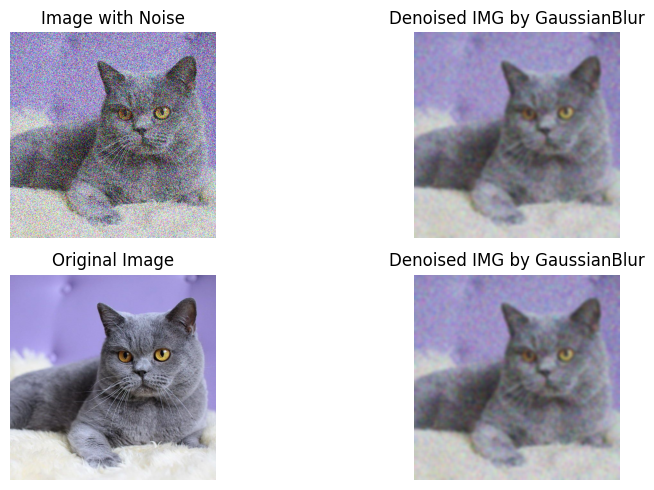

In [24]:
plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(noisy_img, cv.COLOR_BGR2RGB))
plt.title('Image with Noise')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(Gblur, cv.COLOR_BGR2RGB))
plt.title('Denoised IMG by GaussianBlur')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(cat, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(Gblur, cv.COLOR_BGR2RGB))
plt.title('Denoised IMG by GaussianBlur')
plt.axis('off')

plt.tight_layout()

# Section 4
- Add salt and pepper noise to an image using the provided add_salt_and_pepper_noise() function.
- Adjust the ratio parameters of salt_prob and pepper_prob to observe the effect of noise on the image. (2 different ratio parameters)
- Apply Medianblur (cv2.medianBlur) to the image after adding noise, and adjust the blur kernel size to try to denoise. (2 different kernel size)
- Show and compare the results.

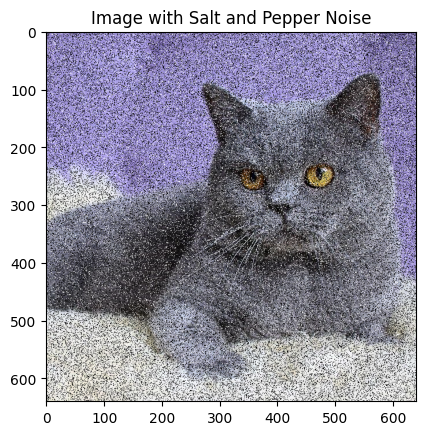

In [25]:
def add_salt_and_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02): # salt_prob = white noise , pepper_prob = black_noise
    noisy_image = image.copy()
    # get image size
    total_pixels = image.size // image.shape[2]
    # calculate the number of noises
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)

    # Add salt noises
    for _ in range(num_salt):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0]) #  Generate random coordinates (x, y)
        noisy_image[y, x] = [255, 255, 255] # white

    # Add pepper noises
    for _ in range(num_pepper):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0])
        noisy_image[y, x] = [0, 0, 0]  # black

    return noisy_image

# Add salt-and-pepper noises to the image
salt_and_pepper_noisy_img = add_salt_and_pepper_noise(cat, salt_prob=0.1, pepper_prob=0.2)

plt.imshow(cv.cvtColor(salt_and_pepper_noisy_img, cv.COLOR_BGR2RGB))
plt.title("Image with Salt and Pepper Noise")
plt.show()

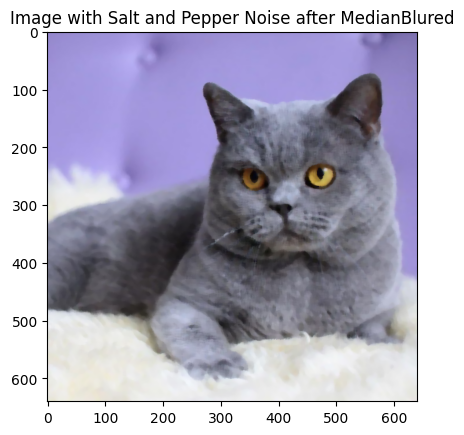

In [26]:
# Answer your code here
# median = cv.medianBlur(input, kernel)
median = cv.medianBlur(salt_and_pepper_noisy_img,7)
plt.imshow(cv.cvtColor(median, cv.COLOR_BGR2RGB))
plt.title("Image with Salt and Pepper Noise after MedianBlured")
plt.show()

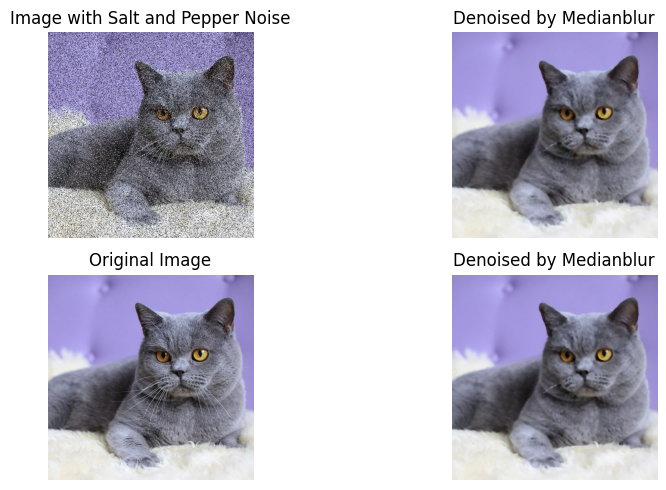

In [27]:
plt.figure(figsize=(10, 5))

plt.subplot(2, 2, 1)
plt.imshow(cv.cvtColor(salt_and_pepper_noisy_img, cv.COLOR_BGR2RGB))
plt.title('Image with Salt and Pepper Noise')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(cv.cvtColor(median, cv.COLOR_BGR2RGB))
plt.title('Denoised by Medianblur')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(cv.cvtColor(cat, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(cv.cvtColor(median, cv.COLOR_BGR2RGB))
plt.title('Denoised by Medianblur')
plt.axis('off')

plt.tight_layout()

# Section 5
Fourier Transform

Use the given image "Lenna" to :
1. Perform the Fourier Transform of the input image and display its magnitude spectrum.

2. Implement the Low-Pass Filter (LPF) using NumPy and the High-Pass Filter (HPF) using OpenCV. Apply both filters to the same input image and compare the output results.

3. Compare how LPF and HPF affect the image. Explain how they influence image sharpness, edges, details, and smoothness. (ตอบสองภาษา)

4. Modify the mask size to 10, 30, 100.
Observe and explain the resulting three types of filtered images for different mask sizes. ลองปรับ mask size  เป็น 10, 30, 100

In [28]:
!gdown '1FNXTuv3OcIg-6o8D9XlhVHhMHGiuAQLA'

Downloading...
From: https://drive.google.com/uc?id=1FNXTuv3OcIg-6o8D9XlhVHhMHGiuAQLA
To: /content/Lenna.png
100% 194k/194k [00:00<00:00, 4.26MB/s]


array([[[226, 137, 124],
        [223, 136, 130],
        [223, 136, 125],
        ...,
        [233, 148, 123],
        [229, 145, 119],
        [206, 108,  96]],

       [[226, 137, 124],
        [223, 136, 130],
        [223, 136, 125],
        ...,
        [232, 147, 123],
        [228, 144, 119],
        [205, 107,  96]],

       [[226, 137, 124],
        [223, 136, 131],
        [223, 137, 125],
        ...,
        [235, 151, 125],
        [232, 149, 122],
        [211, 112,  97]],

       ...,

       [[ 89,  26,  63],
        [ 88,  25,  60],
        [ 91,  26,  63],
        ...,
        [160,  63,  78],
        [168,  66,  77],
        [163,  60,  77]],

       [[ 82,  18,  58],
        [ 90,  24,  58],
        [ 95,  27,  61],
        ...,
        [171,  68,  83],
        [175,  71,  80],
        [176,  67,  79]],

       [[ 81,  21,  56],
        [ 91,  28,  60],
        [ 95,  30,  63],
        ...,
        [176,  70,  82],
        [179,  68,  78],
        [184,  73,  81]]], dtype=uint8)
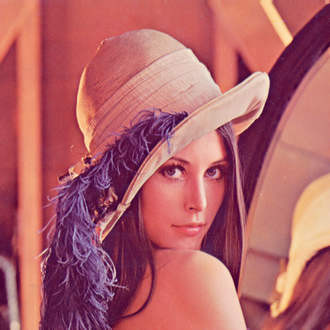

array([[169, 167, 167, ..., 177, 173, 145],
       [169, 167, 167, ..., 175, 173, 144],
       [169, 167, 167, ..., 179, 176, 149],
       ...,
       [ 59,  59,  59, ..., 105, 110, 106],
       [ 53,  59,  61, ..., 112, 115, 115],
       [ 53,  59,  61, ..., 116, 116, 120]], dtype=uint8)
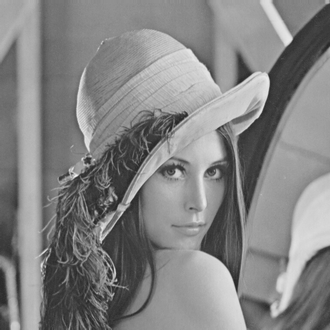

In [29]:
# Answer your code here
# Read the image as grayscale and display.
lennac = cv.imread('/content/Lenna.png', cv.IMREAD_COLOR)
lenna_c = cv.cvtColor(lennac, cv.COLOR_BGR2RGB)
display(lenna_c)
lenna = cv.imread('/content/Lenna.png', cv.IMREAD_GRAYSCALE)
display(lenna)

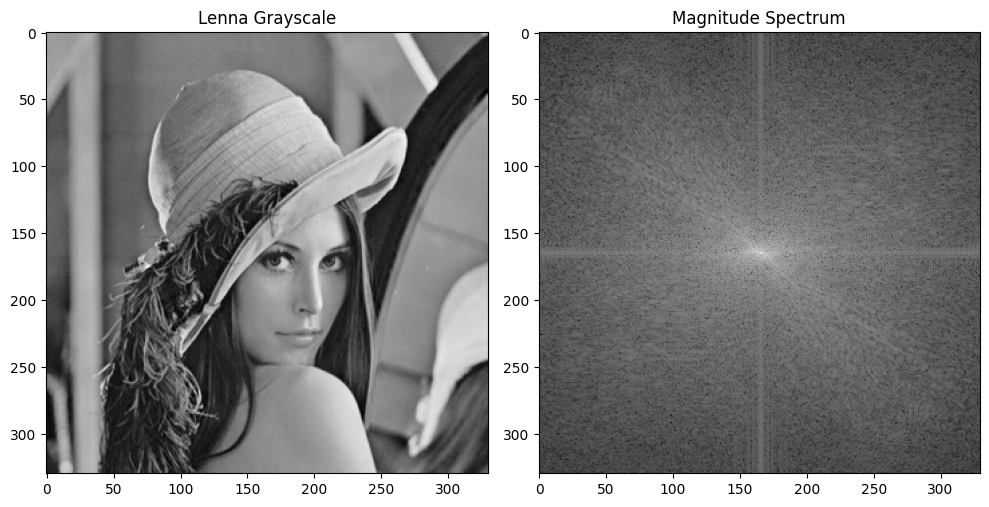

In [42]:
# Answer your code here
f = np.fft.fft2(lenna)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift)+1)  # Add 1 to avoid log(0)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2,1)
plt.imshow(lenna, cmap='gray')
plt.title('Lenna Grayscale')

plt.subplot(1, 2,2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')

plt.tight_layout()
plt.show()

## Low Pass Filter (LPF) using NumPy

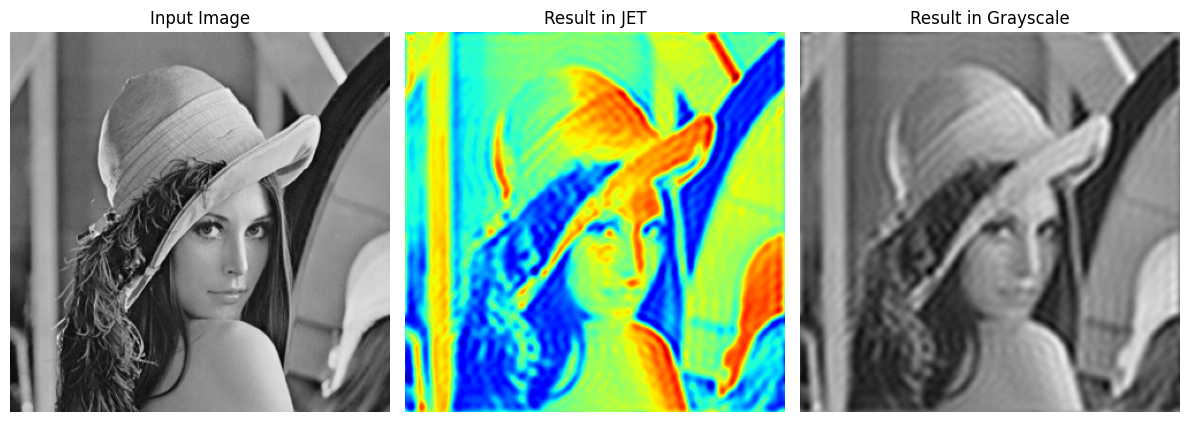

In [47]:
rows, cols = lenna.shape
crow, ccol = rows // 2, cols // 2  # Center coordinates

mask = np.zeros((rows, cols), np.uint8)
mask[crow-30:crow+31, ccol-30:ccol+31] = 1  # Low-frequency region set to 1
# allows low frequencies to pass through (values set to 1) and blocks high frequencies (values set to 0).

fshift_filtered = fshift * mask

# 1. Move the zero-frequency components back to the top-left corner
f_ishift = np.fft.ifftshift(fshift_filtered)

# 2. Perform the Inverse Fourier Transform
img_back = np.fft.ifft2(f_ishift)

# 3. Take the real part of the result to ensure the image is real-valued
img_back = np.real(img_back)
# Normalize the output
img_back -= img_back.min()    # Shift to 0
img_back /= img_back.max()    # Scale to [0, 1]
img_back *= 125               # Scale to [0, 255]
img_back = img_back.astype(np.uint8)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(lenna, cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_back, cmap='jet', vmin=0, vmax=125)
plt.title('Result in JET')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_back, cmap='gray', vmin=0, vmax=125)
plt.title('Result in Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

## High pass filter  (HPF) using OpenCV

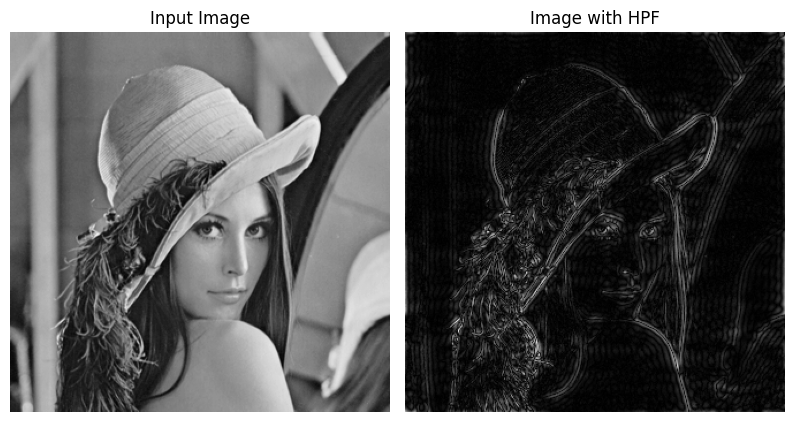

In [32]:
dft = cv.dft(np.float32(lenna), flags=cv.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)
rows, cols = lenna.shape # Get the dimensions of the image (จำนวนแถวและคอลัมน์)

crow, ccol = rows // 2, cols // 2

mask = np.ones((rows, cols, 2), np.uint8)

mask[crow-30:crow+31, ccol-30:ccol+31] = 0   # High pass filter
fshift_lowpass = dft_shift * mask

# Perform the inverse Fourier Transform
f_ishift = np.fft.ifftshift(fshift_lowpass)

# Inverse DFT
img_back = cv.idft(f_ishift)

# Calculate the magnitude, keeping only the real part
img_back = cv.magnitude(img_back[:, :, 0], img_back[:, :, 1])
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(lenna, cmap='gray')
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(img_back, cmap='gray')
plt.title('Image with HPF')
plt.axis('off')

plt.tight_layout()
plt.show()


## **Compare how LPF and HPF affect the image**

**Low-Frequency Components :**

These show the original input images with smooth regions, large color blocks, and overall structure retained.
When the low frequencies are preserved (high frequencies are removed), the image appears blurred or smoothed, with finer details lost.

แสดงภาพต้นฉบับที่มีบริเวณที่เรียบเนียน บล็อกสีขนาดใหญ่ และโครงสร้างโดยรวมของภาพ เมื่อส่วนประกอบความถี่ต่ำถูกเก็บไว้ (และส่วนประกอบความถี่สูงถูกลบออก) ภาพจะดูเบลอหรือเรียบเนียนขึ้น และรายละเอียดที่คมชัดจะหายไป

**High-Frequency Components :**

These show the results of high-pass filtering, where the low-frequency components are removed, leaving only high-frequency components (edges, contours, and fine details).
The result emphasizes sharp edges and outlines of objects while removing smoother regions.

แสดงผลลัพธ์ของการกรองผ่านความถี่สูง ซึ่งลบส่วนประกอบความถี่ต่ำออก และเหลือเฉพาะส่วนประกอบความถี่สูง (ขอบเส้น รูปทรง และรายละเอียดเล็กน้อย) ผลลัพธ์เน้นเส้นขอบที่คมชัดและโครงร่างของวัตถุ ในขณะที่ส่วนที่เรียบเนียนจะถูกลบออก

## Modify Mask

In [33]:
# Define the mask sizes
mask_sizes = [10, 30, 100]

### LPF

Mask Size = 10:
A smaller mask passes a narrow range of low frequencies.
Results in a heavily blurred image with most high-frequency details (like edges) removed.
The image appears smooth and loses fine structures.

จะปล่อยให้ผ่านเฉพาะความถี่ต่ำในช่วงแคบ
ผลลัพธ์คือภาพเบลอมาก โดยรายละเอียดที่มีความถี่สูง (เช่น ขอบหรือเส้นคม) จะถูกลบออก
ภาพจะดูเรียบเนียนและสูญเสียรายละเอียดเล็กๆ น้อยๆ

Mask Size = 30:
A medium-sized mask allows a wider range of low frequencies to pass.
Results in a partially blurred image that retains more details compared to the smaller mask.
The balance between smoothing and detail is more evident.

จะปล่อยให้ผ่านความถี่ต่ำในช่วงที่กว้างขึ้น
ผลลัพธ์คือภาพเบลอเล็กน้อย แต่ยังคงรักษารายละเอียดไว้ได้มากกว่า Mask ขนาดเล็ก
เกิดสมดุลระหว่างการทำให้ภาพเรียบเนียนและการคงรายละเอียด

Mask Size = 100:
A large mask passes an even broader range of frequencies.
The image appears close to the original, with only very high frequencies (fine details) removed.
The effect of smoothing is minimal, preserving most structural details.

จะปล่อยให้ผ่านความถี่ในช่วงที่กว้างมาก
ภาพที่ได้ใกล้เคียงกับภาพต้นฉบับ โดยจะลบเฉพาะรายละเอียดที่มีความถี่สูงมาก (เช่น ลายเส้นเล็กๆ)
ผลของการเบลอน้อยมาก และยังคงรักษารายละเอียดของภาพเกือบทั้งหมด

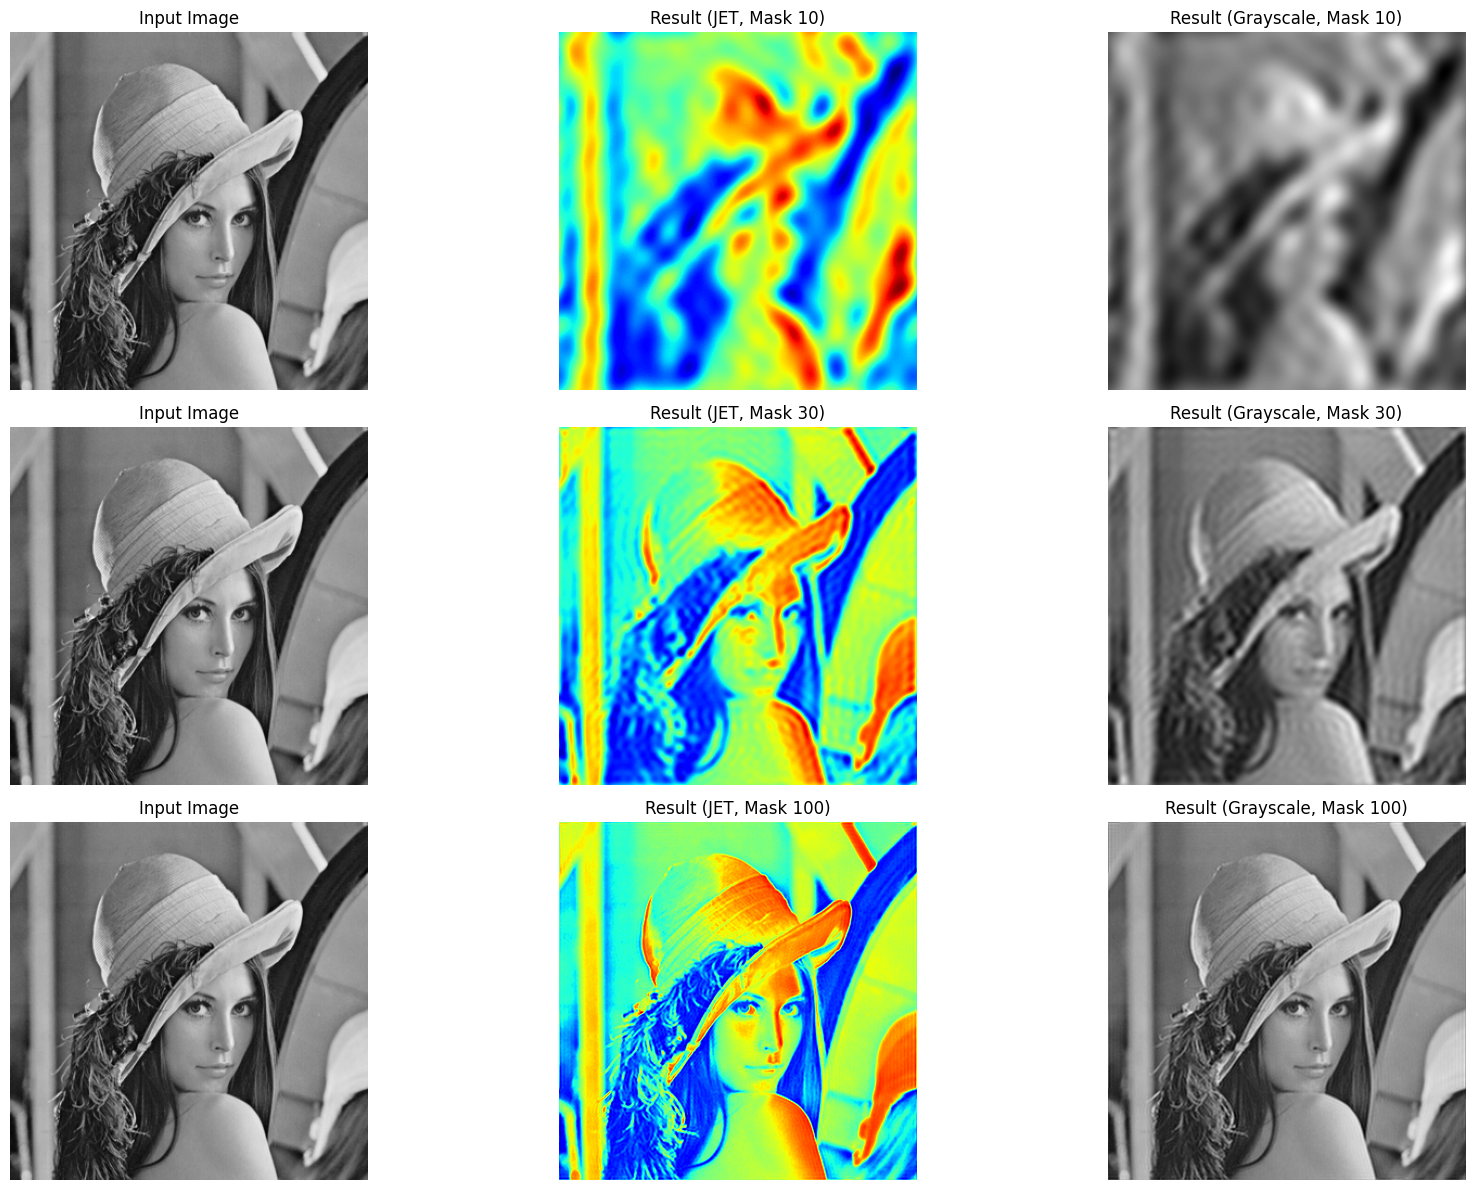

In [48]:
plt.figure(figsize=(18, 12))

for i, size in enumerate(mask_sizes):
    # Reset the Fourier transform
    fshift = np.fft.fftshift(np.fft.fft2(lenna))

    mask = np.zeros_like(fshift, dtype=np.uint8)
    mask[crow-size:crow+size+1, ccol-size:ccol+size+1] = 1
    # Apply a square mask for low-pass filtering
    fshift_filtered = fshift * mask

    # 1. Move the zero-frequency components back to the top-left corner
    f_ishift = np.fft.ifftshift(fshift_filtered)

    # 2. Perform the Inverse Fourier Transform
    img_back = np.fft.ifft2(f_ishift)

    # 3. Take the real part of the result to ensure the image is real-valued
    img_back = np.real(img_back)
    # Normalize the output
    img_back -= img_back.min()    # Shift to 0
    img_back /= img_back.max()    # Scale to [0, 1]
    img_back *= 125              # Scale to [0, 255]
    img_back = img_back.astype(np.uint8)

    # Plot the results
    plt.subplot(3, 3, 3 * i + 1)
    plt.imshow(lenna, cmap='gray')
    plt.title(f'Input Image')
    plt.axis('off')

    plt.subplot(3, 3, 3 * i + 2)
    plt.imshow(img_back, cmap='jet', vmin=0, vmax=125)
    plt.title(f'Result (JET, Mask {size})')
    plt.axis('off')

    plt.subplot(3, 3, 3 * i + 3)
    plt.imshow(img_back, cmap='gray', vmin=0, vmax=125)
    plt.title(f'Result (Grayscale, Mask {size})')
    plt.axis('off')

plt.tight_layout()
plt.show()

### HPF

Mask Size = 10:
A smaller mask blocks only a very narrow region of low frequencies.
The resulting image retains most of the fine details (edges and textures) but removes most of the smoother transitions and low-frequency components.
This creates a very sharp, edge-enhanced image with high contrast at edges.

จะบล็อกเฉพาะบริเวณความถี่ต่ำที่อยู่ตรงศูนย์กลางของภาพในโดเมนความถี่
ส่งผลให้ความถี่สูงส่วนใหญ่ยังคงอยู่ในภาพ ซึ่งเน้นขอบและรายละเอียดที่คมชัด
ภาพที่ได้จะมีขอบที่เด่นชัดและยังคงมีพื้นหลังบางส่วนอยู่

Mask Size = 30:
A medium mask blocks a wider range of low frequencies.
The resulting image shows more pronounced sharpening of edges, and smooth areas become darker or noisier due to the absence of low frequencies.
The balance between edge emphasis and background distortion becomes more noticeable.

บล็อกความถี่ต่ำในช่วงที่กว้างขึ้น
ส่งผลให้ภาพเน้นขอบและรายละเอียดที่มีความคมชัดสูงมากขึ้น ในขณะที่พื้นหลังเริ่มสูญเสียความนุ่มนวล
พื้นที่ที่เรียบเนียนในต้นฉบับ สีระหว่างขอบและพื้นหลังเห็นชัดมากขึ้น

Mask Size = 100:
A larger mask blocks a broad range of low frequencies.
The resulting image is dominated by high-frequency components, making it appear as an outline or edge map of the original.
Most smooth areas and tonal gradations are eliminated, leaving only prominent edges and fine details.

ภาพจะเหลือเพียงข้อมูลความถี่สูงที่เน้นแต่ขอบและรายละเอียดเท่านั้น
พื้นที่ส่วนใหญ่ของภาพ (รวมถึงพื้นหลังและใบหน้า) จะหายไปและเหลือแต่ส่วนที่มีการเปลี่ยนแปลงของความเข้มสูง (ขอบและโครงสร้างเล็กๆ)

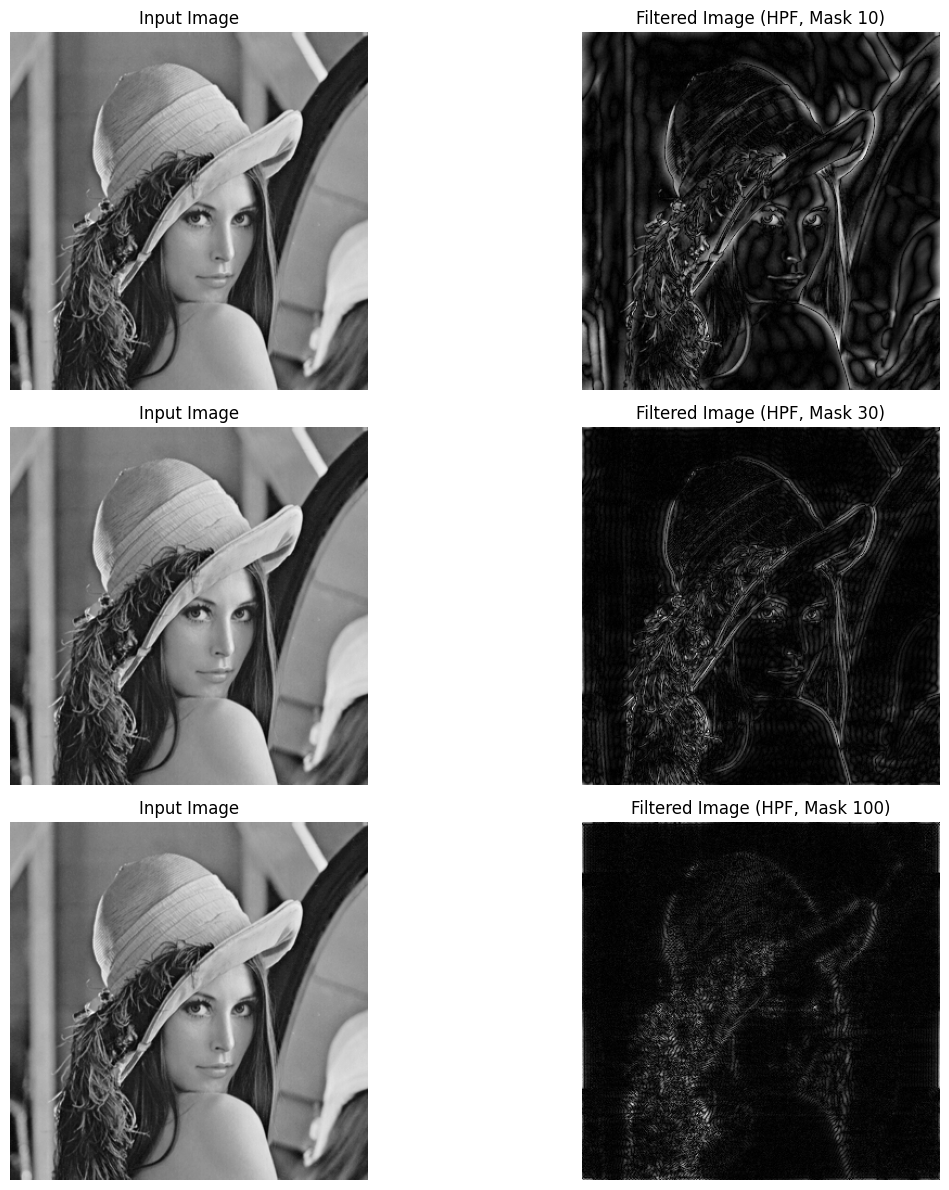

In [35]:
plt.figure(figsize=(18, 12))

for i, size in enumerate(mask_sizes):
    # Reset the DFT and shift
    dft = cv.dft(np.float32(lenna), flags=cv.DFT_COMPLEX_OUTPUT)
    dft_shift = np.fft.fftshift(dft)

    # Create the mask
    mask = np.ones((rows, cols, 2), np.uint8)
    mask[crow-size:crow+size+1, ccol-size:ccol+size+1] = 0  # High-pass filter

    # Apply the mask
    fshift_highpass = dft_shift * mask

    # Perform the inverse Fourier Transform
    f_ishift = np.fft.ifftshift(fshift_highpass)
    img_back = cv.idft(f_ishift)

    # Calculate the magnitude (real part only)
    img_back = cv.magnitude(img_back[:, :, 0], img_back[:, :, 1])

    # Plot the results
    plt.subplot(3, 3, 3 * i + 1)
    plt.imshow(lenna, cmap='gray')
    plt.title(f'Input Image')
    plt.axis('off')

    plt.subplot(3, 3, 3 * i + 2)
    plt.imshow(img_back, cmap='gray')
    plt.title(f'Filtered Image (HPF, Mask {size})')
    plt.axis('off')

plt.tight_layout()
plt.show()